# Unit 5 — Combining models

The practice questions of this unit (21CSC305P). Every question below is self-contained: run any cell on its own. All questions use the Seattle daily weather data (`website/data/seattle_weather.csv`); models are trained on 2012–2014 and tested on 2015.

In [1]:
%config InlineBackend.figure_format = "svg"
import sys
sys.path.insert(0, "website")          # weather.py and the data live in website/
from weather import use_style
use_style()

## Practice 1 — Implement CART learning algorithms to perform categorization

CART grows a tree by repeatedly asking the yes/no question that makes the two groups purest, measured by Gini impurity. We write the algorithm from scratch, print the tree, check it against scikit-learn and see how depth affects over-fitting.

if precipitation <= 0.30:
    -> no rain
else:
    if month_cos <= 0.00:
        if precipitation <= 6.90:
            -> no rain
        else:
            -> RAIN
    else:
        -> RAIN

test accuracy (2015): our CART 0.725 | scikit-learn 0.717 | 'tomorrow = today' 0.703


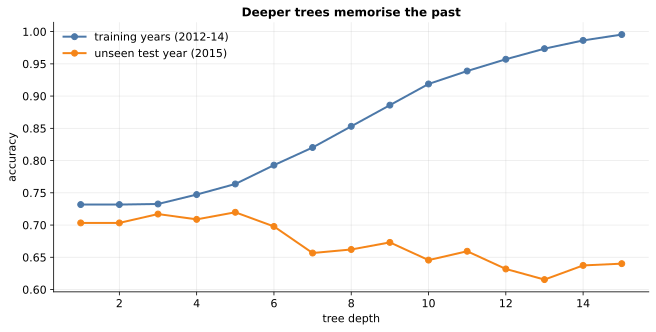

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from weather import load, split, FEATURES

train, test = split(load())
X, y = train[FEATURES].values, train.rain_tomorrow.values.astype(int)
Xt, yt = test[FEATURES].values, test.rain_tomorrow.values.astype(int)
gini = lambda y: 1 - y.mean() ** 2 - (1 - y.mean()) ** 2                       # 0 = pure group

def best_split(X, y):
    best = (np.inf, None, None)
    for j in range(X.shape[1]):
        for thr in np.unique(X[:, j])[:-1]:
            left = X[:, j] <= thr
            score = (left.sum() * gini(y[left]) + (~left).sum() * gini(y[~left])) / len(y)
            if score < best[0]: best = (score, j, thr)
    return best

def grow(X, y, depth, max_depth, min_leaf=20):
    if depth == max_depth or len(y) < 2 * min_leaf or gini(y) == 0: return int(y.mean() > .5)
    _, j, thr = best_split(X, y)
    left = X[:, j] <= thr
    if left.sum() < min_leaf or (~left).sum() < min_leaf: return int(y.mean() > .5)
    a, b = grow(X[left], y[left], depth + 1, max_depth), grow(X[~left], y[~left], depth + 1, max_depth)
    return a if a == b and not isinstance(a, tuple) else (j, thr, a, b)     # both sides say the same: no question needed

def predict_one(node, x):
    while isinstance(node, tuple): node = node[2] if x[node[0]] <= node[1] else node[3]
    return node

def show(node, indent=""):
    if not isinstance(node, tuple): print(indent + ("-> RAIN" if node else "-> no rain")); return
    print(f"{indent}if {FEATURES[node[0]]} <= {round(node[1], 2) + 0.0:.2f}:"); show(node[2], indent + "    ")
    print(f"{indent}else:"); show(node[3], indent + "    ")

tree = grow(X, y, 0, 3)
show(tree)
ours = np.array([predict_one(tree, x) for x in Xt])
sk = DecisionTreeClassifier(max_depth=3, min_samples_leaf=20, random_state=0).fit(X, y)
print(f"\ntest accuracy (2015): our CART {np.mean(ours == yt):.3f} | scikit-learn {sk.score(Xt, yt):.3f} | 'tomorrow = today' {np.mean(test.rain.values == yt):.3f}")

depths = range(1, 16)
fit_acc, test_acc = [], []
for dep in depths:
    t = DecisionTreeClassifier(max_depth=dep, random_state=0).fit(X, y)
    fit_acc.append(t.score(X, y)); test_acc.append(t.score(Xt, yt))
plt.figure(figsize=(9, 4.5))
plt.plot(depths, fit_acc, "o-", label="training years (2012-14)"); plt.plot(depths, test_acc, "o-", label="unseen test year (2015)")
plt.xlabel("tree depth"); plt.ylabel("accuracy"); plt.title("Deeper trees memorise the past"); plt.legend(); plt.show()

## Practice 2 — Implement Ensemble learning models to perform classification

An ensemble combines many models into one. Bagging averages trees trained on random re-samples, a random forest also picks features at random, boosting adds trees one after another to fix earlier mistakes, and voting combines different kinds of model.

'tomorrow = today' accuracy: 0.703

voting (logistic + forest + boosting)    0.728
random forest                            0.717
AdaBoost                                 0.712
gradient boosting                        0.709
bagging (100 trees)                      0.706
single tree                              0.687


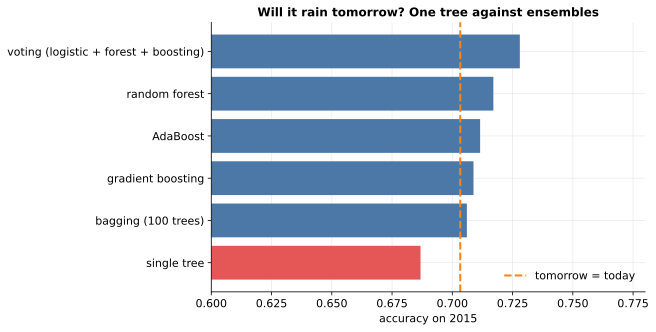

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (BaggingClassifier, RandomForestClassifier, AdaBoostClassifier,
                              GradientBoostingClassifier, VotingClassifier)
from weather import load, split, FEATURES

train, test = split(load())
X, y = train[FEATURES].values, train.rain_tomorrow.values.astype(int)
Xt, yt = test[FEATURES].values, test.rain_tomorrow.values.astype(int)
baseline = np.mean(test.rain.values == yt)

tree = DecisionTreeClassifier(min_samples_leaf=10, random_state=0)
rf = RandomForestClassifier(150, min_samples_leaf=5, random_state=0)
gb = GradientBoostingClassifier(n_estimators=100, max_depth=2, learning_rate=.05, random_state=0)
models = {
    "single tree": tree,
    "bagging (100 trees)": BaggingClassifier(tree, n_estimators=100, random_state=0),
    "random forest": rf,
    "AdaBoost": AdaBoostClassifier(n_estimators=100, random_state=0),
    "gradient boosting": gb,
    "voting (logistic + forest + boosting)": VotingClassifier([("lr", LogisticRegression(max_iter=1000)), ("rf", rf), ("gb", gb)], voting="soft"),
}
scores = pd.Series({name: m.fit(X, y).score(Xt, yt) for name, m in models.items()}).sort_values()
print(f"'tomorrow = today' accuracy: {baseline:.3f}\n")
print(scores.sort_values(ascending=False).round(3).to_string())

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(scores.index, scores.values, color=["#e45756" if n == "single tree" else "#4c78a8" for n in scores.index])
ax.axvline(baseline, color="#f58518", ls="--", label="tomorrow = today")
ax.set_xlim(.6, .78); ax.set_xlabel("accuracy on 2015")
ax.set_title("Will it rain tomorrow? One tree against ensembles"); ax.legend(loc="lower right")
plt.show()